# Ocean Color Algorithms

Ocean color products depend on calibration, validation, and algorithms. Satellite sensors are routinely compared against in situ measurements to ensure that the radiances and derived products are physically meaningful.

Important in situ observations include:

- Downwelling irradiance at the ocean surface
- Water-leaving radiance
- Chlorophyll-a concentration
- Bio-optical properties such as absorption and scattering

Examples of calibration and validation resources include MOBY and SeaBASS.

## The General Chlorophyll-a Algorithm

Many empirical chlorophyll-a algorithms can be written in two steps.

First, compute a log-transformed blue-green band ratio:

$$R = \log_{10}\left(\frac{\max(R_{rs}(\lambda_{blue}))}{R_{rs}(\lambda_{green})}\right)$$

Then estimate chlorophyll-a using a polynomial relationship:

$$\log_{10}(Chl) = a_0 + a_1R + a_2R^2 + a_3R^3 + a_4R^4$$

or equivalently:

$$Chl = 10^{a_0 + a_1R + a_2R^2 + a_3R^3 + a_4R^4}$$

The blue and green wavelengths differ by satellite sensor, so the coefficients $a_0$ through $a_4$ also differ by sensor and processing version. The following table shows some values for common sensors:

|Sensor|Blue Wavelength (nm)|Green Wavelength (nm)|$a_0$|$a_1$|$a_2$|$a_3$|$a_4$|
|------|----|-----|--|--|--|--|--|
|CZCS|max(443,520)|550|0.3330|-4.3770|7.6267|-7.1457|1.6673|
|SeaWiFS|max(443,489,510)|555|0.3272|-2.9940|2.7218|-1.2259|-0.5683|
|MODIS|max(443,489)|547|0.2424|-2.7423|1.8017|0.0015|-1.2280|
|VIIRS|max(443,486)|550|0.2228|-2.4683|1.5867|-0.4275|-0.7768|

This table was adapted from the information on the [NASA Ocean Color Chlorophyll](https://oceancolor.gsfc.nasa.gov/data/reprocessing/r2009/ocv6/) processing page.

In [10]:
def ocx_chlorophyll(Rrs_blue, Rrs_green, coeffs=(0.25, -2.6, 1.5, -0.5, -0.2)):
    """Illustrative OCx-style chlorophyll-a algorithm.
    
    These coefficients are for teaching only. Operational products use
    sensor-specific coefficients and additional quality controls.
    """
    R = np.log10(Rrs_blue / Rrs_green)
    a0, a1, a2, a3, a4 = coeffs
    log_chl = a0 + a1*R + a2*R**2 + a3*R**3 + a4*R**4
    return 10**log_chl, R

# Example reflectance values
examples = pd.DataFrame({
    'Water Type': ['Clear blue water', 'Moderate chlorophyll', 'Green productive water'],
    'Rrs_blue': [0.010, 0.006, 0.003],
    'Rrs_green': [0.003, 0.004, 0.005]
})

examples['Estimated Chl-a'], examples['R'] = ocx_chlorophyll(examples['Rrs_blue'], examples['Rrs_green'])
examples[['Water Type', 'Rrs_blue', 'Rrs_green', 'R', 'Estimated Chl-a']]

,Water Type,Rrs_blue,Rrs_green,R,Estimated Chl-a
0,Clear blue water,0.010,0.003,0.522879,0.163754
1,Moderate chlorophyll,0.006,0.004,0.176091,0.685098
2,Green productive water,0.003,0.005,-0.221849,8.046499


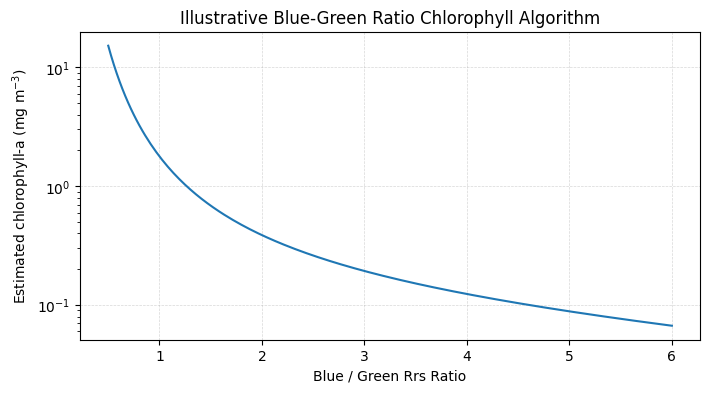

In [11]:
# Plot the illustrative algorithm response
ratios = np.linspace(0.5, 6, 200)
Rrs_green = np.ones_like(ratios) * 0.004
Rrs_blue = ratios * Rrs_green
chl_est, R = ocx_chlorophyll(Rrs_blue, Rrs_green)

plt.figure(figsize=(8,4))
plt.semilogy(ratios, chl_est)
plt.xlabel('Blue / Green Rrs Ratio')
plt.ylabel('Estimated chlorophyll-a (mg m$^{-3}$)')
plt.title('Illustrative Blue-Green Ratio Chlorophyll Algorithm')
plt.grid(linestyle='--', linewidth=0.5, alpha=0.5)
plt.show()